# Group 51 — Waste Classification Training

**Backend:** PyTorch with Apple MPS (Metal Performance Shaders)  
**Model:** EfficientNetB0 pretrained on ImageNet, fine-tuned for 8 waste classes  
**Secondary model:** MobileNetV2 for clean vs contaminated condition detection

### Before running:
1. Make sure your virtual env is active: `source waste_env/bin/activate`
2. Make sure the kernel is set to **Python (waste_env)** — Kernel → Change kernel
3. Your `dataset/` folder should be at `~/Downloads/Capstone_project/files/dataset/`  
   (or update `DATASET_PATH` in Cell 2)

## Cell 1 — Check environment and MPS

In [1]:
import sys, os, platform
import torch
import torchvision

print(f'Python       : {sys.version}')
print(f'Platform     : {platform.platform()}')
print(f'PyTorch      : {torch.__version__}')
print(f'Torchvision  : {torchvision.__version__}')
print()

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Device: MPS (Apple Silicon GPU) — training will be accelerated')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'Device: CUDA GPU — {torch.cuda.get_device_name(0)}')
else:
    DEVICE = torch.device('cpu')
    print('Device: CPU only — training will be slow, consider reducing epochs')

print(f'\nUsing device: {DEVICE}')

# Quick MPS sanity check
if DEVICE.type == 'mps':
    try:
        t = torch.zeros(1, device=DEVICE)
        print('MPS tensor test passed.')
    except Exception as e:
        print(f'MPS test failed: {e}. Falling back to CPU.')
        DEVICE = torch.device('cpu')

Python       : 3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 17.0.0 (clang-1700.6.3.2)]
Platform     : macOS-26.5.1-arm64-arm-64bit
PyTorch      : 2.11.0
Torchvision  : 0.26.0

Device: MPS (Apple Silicon GPU) — training will be accelerated

Using device: mps
MPS tensor test passed.


## Cell 2 — Config (edit paths and hyperparameters here)

In [2]:
import os
from pathlib import Path

# ── PATHS — update DATASET_PATH if your folder is somewhere else ───────────
DATASET_PATH  = Path(os.path.expanduser('~/Downloads/Capstone_project/model_and_data_pipeline/dataset_v2'))
MODELS_DIR    = Path(os.path.expanduser('~/Downloads/Capstone_project/model_and_data_pipeline/models_v2'))
TRAIN_DIR     = DATASET_PATH / 'train'
VAL_DIR       = DATASET_PATH / 'val'
TEST_DIR      = DATASET_PATH / 'test'

MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── PRIMARY MODEL HYPERPARAMETERS ─────────────────────────────────────────
IMG_SIZE        = 224      # EfficientNetB0 native size
BATCH_SIZE      = 32       # M4 16GB handles this fine; reduce to 16 if you see memory errors
EPOCHS_PHASE1   = 10       # frozen base — fast, just trains the head
EPOCHS_PHASE2   = 20       # fine-tuning — slower, improves accuracy
LR_PHASE1       = 1e-3
LR_PHASE2       = 1e-5
UNFREEZE_LAYERS = 30       # how many layers from the top of EfficientNet to unfreeze
DROPOUT_RATE    = 0.4
LABEL_SMOOTHING = 0.1
NUM_WORKERS     = 0       # parallel data loading — M4 has 10 cores, 4 is safe

# ── SECONDARY (CONDITION) MODEL ────────────────────────────────────────────
COND_EPOCHS     = 15
COND_LR         = 1e-4

# ── REPRODUCIBILITY ────────────────────────────────────────────────────────
SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── VALIDATE PATHS ─────────────────────────────────────────────────────────
missing = [d for d in [TRAIN_DIR, VAL_DIR, TEST_DIR] if not d.exists()]
if missing:
    raise FileNotFoundError(
        f'These dataset folders are missing:\n' +
        '\n'.join(f'  {d}' for d in missing) +
        '\nUpdate DATASET_PATH in this cell.'
    )

print('Config loaded.')
print(f'  Dataset   : {DATASET_PATH}')
print(f'  Models out: {MODELS_DIR}')
print(f'  Device    : {DEVICE}')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  Phase 1   : {EPOCHS_PHASE1} epochs @ lr={LR_PHASE1}')
print(f'  Phase 2   : {EPOCHS_PHASE2} epochs @ lr={LR_PHASE2}')

Config loaded.
  Dataset   : /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/dataset_v2
  Models out: /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/models_v2
  Device    : mps
  Batch size: 32
  Phase 1   : 10 epochs @ lr=0.001
  Phase 2   : 20 epochs @ lr=1e-05


## Cell 3 — Inspect dataset

In [3]:
VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def count_images(split_dir):
    counts = {}
    for cls_dir in sorted(Path(split_dir).iterdir()):
        if cls_dir.is_dir():
            counts[cls_dir.name] = sum(
                1 for f in cls_dir.iterdir() if f.suffix.lower() in VALID_EXT
            )
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

CLASS_NAMES = sorted(train_counts.keys())
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: cls for cls, i in CLASS_TO_IDX.items()}

import json
with open(MODELS_DIR / 'class_indices.json', 'w') as f:
    json.dump(CLASS_TO_IDX, f, indent=2)

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print()
print(f'{"Class":<16} {"Train":>8} {"Val":>8} {"Test":>8} {"Total":>9}')
print('─' * 53)
grand = 0
for cls in CLASS_NAMES:
    tr  = train_counts.get(cls, 0)
    va  = val_counts.get(cls, 0)
    te  = test_counts.get(cls, 0)
    tot = tr + va + te
    grand += tot
    flag = '  <-- augmentation recommended' if tr < 1000 else ''
    print(f'{cls:<16} {tr:>8,} {va:>8,} {te:>8,} {tot:>9,}{flag}')
print('─' * 53)
print(f'{"TOTAL":<16} {sum(train_counts.values()):>8,} '
      f'{sum(val_counts.values()):>8,} '
      f'{sum(test_counts.values()):>8,} {grand:>9,}')
print(f'\nclass_indices.json saved to {MODELS_DIR}')

Classes (8): ['e-waste', 'general_trash', 'glass', 'hazardous', 'metal', 'organic', 'paper', 'plastic']

Class               Train      Val     Test     Total
─────────────────────────────────────────────────────
e-waste             2,209      473      474     3,156
general_trash       6,320    1,354    1,354     9,028
glass               2,888      619      619     4,126
hazardous           1,500      147      146     1,793
metal               1,831      392      392     2,615
organic            16,288    3,490    3,490    23,268
paper               5,286    1,133    1,133     7,552
plastic            11,075    2,374    2,374    15,823
─────────────────────────────────────────────────────
TOTAL              47,397    9,982    9,982    67,361

class_indices.json saved to /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/models_v2


## Cell 4 — Visualise sample images

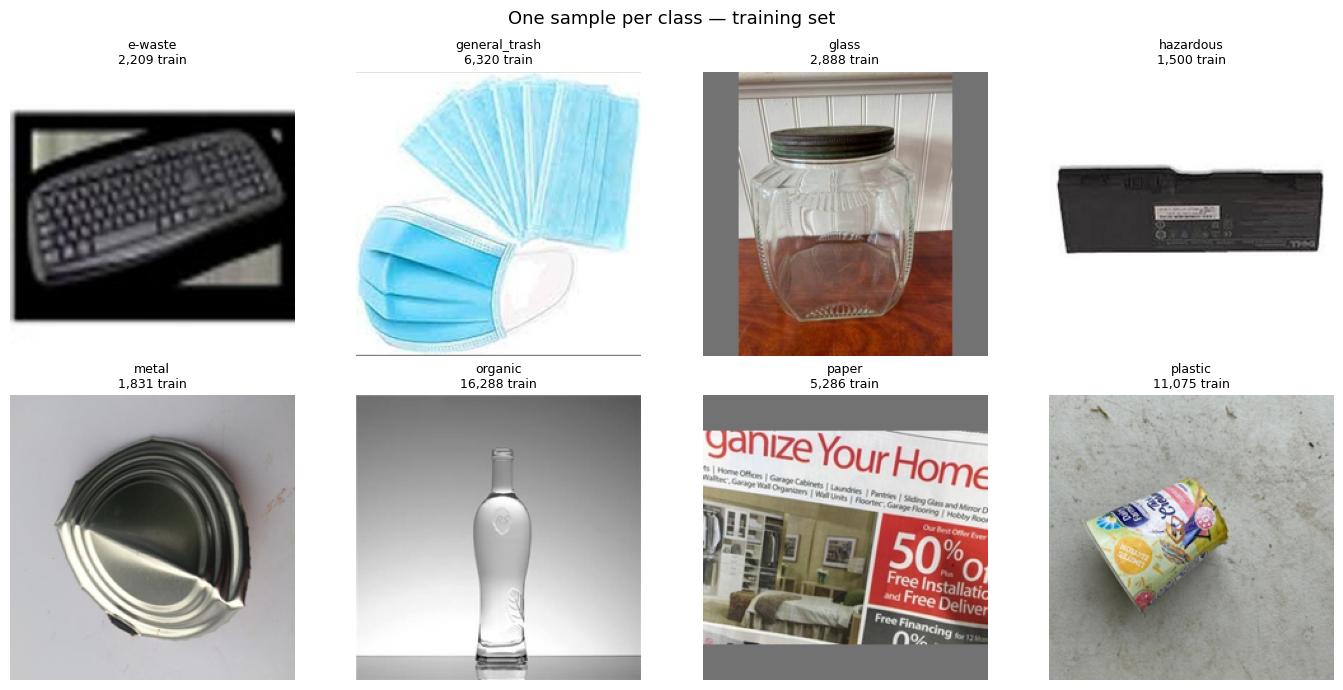

Saved sample_images.png


In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import random

rows = (NUM_CLASSES + 3) // 4
fig, axes = plt.subplots(rows, 4, figsize=(14, rows * 3.5))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    cls_dir = TRAIN_DIR / cls
    imgs = [f for f in cls_dir.iterdir() if f.suffix.lower() in VALID_EXT]
    if not imgs:
        axes[i].set_visible(False)
        continue
    try:
        img = Image.open(random.choice(imgs)).convert('RGB').resize((224, 224))
        axes[i].imshow(img)
        axes[i].set_title(f'{cls}\n{train_counts[cls]:,} train', fontsize=9)
        axes[i].axis('off')
    except Exception:
        axes[i].set_visible(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('One sample per class — training set', fontsize=13)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved sample_images.png')

## Cell 5 — Build PyTorch dataset and dataloaders

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

# ── IMAGENET MEAN/STD (required for pretrained EfficientNet) ───────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── TRANSFORMS ────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),   # slightly larger then crop
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── CUSTOM DATASET ────────────────────────────────────────────────────────
class WasteDataset(Dataset):
    def __init__(self, root_dir, class_to_idx, transform=None):
        self.samples = []
        self.transform = transform
        root_dir = Path(root_dir)
        for cls_name, idx in class_to_idx.items():
            cls_dir = root_dir / cls_name
            if not cls_dir.exists():
                continue
            for img_path in cls_dir.iterdir():
                if img_path.suffix.lower() in VALID_EXT:
                    self.samples.append((str(img_path), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            # Return a black image if file is corrupt — won't crash training
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))
        if self.transform:
            image = self.transform(image)
        return image, label

# ── BUILD DATASETS ────────────────────────────────────────────────────────
train_dataset = WasteDataset(TRAIN_DIR, CLASS_TO_IDX, transform=train_transform)
val_dataset   = WasteDataset(VAL_DIR,   CLASS_TO_IDX, transform=val_transform)
test_dataset  = WasteDataset(TEST_DIR,  CLASS_TO_IDX, transform=val_transform)

# ── CLASS WEIGHTS for imbalanced classes ─────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

all_labels = [label for _, label in train_dataset.samples]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=all_labels
)
CLASS_WEIGHTS_TENSOR = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print('Class weights (higher = rarer, gets more attention):')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:<16} {class_weights[i]:.3f}')

# ── DATALOADERS ───────────────────────────────────────────────────────────
# pin_memory only works with CUDA; for MPS we leave it False
pin = (DEVICE.type == 'cuda')

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=pin, 
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin, 
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin, 
)

print(f'\nTrain   : {len(train_dataset):,} images, {len(train_loader)} batches')
print(f'Val     : {len(val_dataset):,} images, {len(val_loader)} batches')
print(f'Test    : {len(test_dataset):,} images, {len(test_loader)} batches')

Class weights (higher = rarer, gets more attention):
  e-waste          2.682
  general_trash    0.937
  glass            2.051
  hazardous        3.950
  metal            3.236
  organic          0.364
  paper            1.121
  plastic          0.535

Train   : 47,397 images, 1482 batches
Val     : 9,982 images, 312 batches
Test    : 9,982 images, 312 batches


## Cell 6 — Build primary model (EfficientNetB0)

In [6]:
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def build_primary_model(num_classes, dropout_rate=0.4):
    # Load EfficientNetB0 with pretrained ImageNet weights
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

    # Freeze all base layers for Phase 1
    for param in model.parameters():
        param.requires_grad = False

    # Replace the classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(p=dropout_rate / 2),
        nn.Linear(256, num_classes)
    )
    # Classifier head is trainable by default (new layers always are)
    return model

primary_model = build_primary_model(NUM_CLASSES, DROPOUT_RATE)
primary_model = primary_model.to(DEVICE)

total_params     = sum(p.numel() for p in primary_model.parameters())
trainable_params = sum(p.numel() for p in primary_model.parameters() if p.requires_grad)

print(f'Model         : EfficientNetB0')
print(f'Total params  : {total_params:,}')
print(f'Trainable     : {trainable_params:,}  (phase 1 — head only)')
print(f'Frozen        : {total_params - trainable_params:,}')
print(f'Device        : {DEVICE}')

Model         : EfficientNetB0
Total params  : 4,338,052
Trainable     : 330,504  (phase 1 — head only)
Frozen        : 4,007,548
Device        : mps


## Cell 7 — Training helpers (train loop, eval loop, plotting)

In [7]:
import time
import copy
from tqdm import tqdm
import matplotlib.pyplot as plt

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False, desc='  train'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False, desc='  eval'):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


def run_training(model, train_loader, val_loader, criterion, optimizer, scheduler,
                 epochs, device, save_path, phase_name=''):
    best_val_acc   = 0.0
    best_weights   = copy.deepcopy(model.state_dict())
    patience_count = 0
    PATIENCE       = 7

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        elapsed = time.time() - t0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        improved = '*' if val_acc > best_val_acc else ' '
        print(f'[{phase_name}] Epoch {epoch:02d}/{epochs} | '
              f'train loss {train_loss:.4f} acc {train_acc:.4f} | '
              f'val loss {val_loss:.4f} acc {val_acc:.4f} | '
              f'{elapsed:.0f}s {improved}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, save_path)
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f'  Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
                break

    # Restore best weights
    model.load_state_dict(best_weights)
    print(f'\nBest val accuracy [{phase_name}]: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
    return history


def plot_history(histories, phase_names, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    offset = 0
    colors = [('#2196F3', '#FF9800'), ('#4CAF50', '#F44336')]
    for i, (hist, name) in enumerate(zip(histories, phase_names)):
        n = len(hist['train_acc'])
        xs = range(offset + 1, offset + n + 1)
        c = colors[i % len(colors)]
        axes[0].plot(xs, hist['train_acc'], color=c[0], label=f'{name} train', linewidth=2)
        axes[0].plot(xs, hist['val_acc'],   color=c[1], label=f'{name} val',   linewidth=2)
        axes[1].plot(xs, hist['train_loss'], color=c[0], label=f'{name} train', linewidth=2)
        axes[1].plot(xs, hist['val_loss'],   color=c[1], label=f'{name} val',   linewidth=2)
        if i < len(histories) - 1:
            axes[0].axvline(offset + n + 0.5, color='gray', linestyle='--', alpha=0.5)
            axes[1].axvline(offset + n + 0.5, color='gray', linestyle='--', alpha=0.5)
        offset += n

    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].set_title('Loss');      axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss');     axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.suptitle('Primary model — training history', fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved training history plot → {save_path}')

print('Training helpers defined.')

Training helpers defined.


## Cell 8 — Phase 1: Train classifier head (base frozen)

In [8]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss(
    weight=CLASS_WEIGHTS_TENSOR,
    label_smoothing=LABEL_SMOOTHING
)

# Only optimise the classifier head parameters
optimizer_p1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, primary_model.parameters()),
    lr=LR_PHASE1
)
scheduler_p1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1, mode='min', factor=0.5, patience=3, 
)

PHASE1_SAVE = str(MODELS_DIR / 'primary_phase1_best.pth')

print('='*55)
print('PHASE 1 — Feature extraction (base frozen)')
print(f'Trainable params: {sum(p.numel() for p in primary_model.parameters() if p.requires_grad):,}')
print('='*55)

history_p1 = run_training(
    primary_model, train_loader, val_loader,
    criterion, optimizer_p1, scheduler_p1,
    epochs=EPOCHS_PHASE1, device=DEVICE,
    save_path=PHASE1_SAVE, phase_name='Phase1'
)
print(f'Phase 1 weights saved → {PHASE1_SAVE}')

PHASE 1 — Feature extraction (base frozen)
Trainable params: 330,504


[Phase1] Epoch 01/10 | train loss 1.5232 acc 0.5664 | val loss 1.8428 acc 0.6703 | 290s *


[Phase1] Epoch 02/10 | train loss 1.4493 acc 0.6071 | val loss 1.8391 acc 0.6758 | 313s *


[Phase1] Epoch 03/10 | train loss 1.4187 acc 0.6225 | val loss 1.8331 acc 0.6761 | 1212s *


[Phase1] Epoch 04/10 | train loss 1.4030 acc 0.6332 | val loss 1.8050 acc 0.6932 | 326s *


...

[Phase1] Epoch 06/10 | train loss 1.3723 acc 0.6509 | val loss 1.7769 acc 0.7104 | 352s  


[Phase1] Epoch 07/10 | train loss 1.3600 acc 0.6538 | val loss 1.7744 acc 0.7138 | 355s *


[Phase1] Epoch 08/10 | train loss 1.3549 acc 0.6610 | val loss 1.7589 acc 0.7176 | 360s *


[Phase1] Epoch 09/10 | train loss 1.3402 acc 0.6676 | val loss 1.7382 acc 0.7368 | 362s *


[Phase1] Epoch 10/10 | train loss 1.3370 acc 0.6695 | val loss 1.7577 acc 0.7210 | 364s  

Best val accuracy [Phase1]: 0.7368 (73.68%)
Phase 1 weights saved → /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/models_v2/primary_phase1_best.pth


## Cell 9 — Phase 2: Fine-tune (unfreeze top layers)

In [9]:
# Unfreeze the last UNFREEZE_LAYERS layers of the EfficientNet features
all_feature_layers = list(primary_model.features.parameters())
total_feature_params = len(all_feature_layers)
unfreeze_from = max(0, total_feature_params - UNFREEZE_LAYERS)

for i, param in enumerate(primary_model.features.parameters()):
    param.requires_grad = (i >= unfreeze_from)

# Classifier head is already trainable
for param in primary_model.classifier.parameters():
    param.requires_grad = True

trainable_now = sum(p.numel() for p in primary_model.parameters() if p.requires_grad)
print(f'Unfroze last {UNFREEZE_LAYERS} feature parameter tensors.')
print(f'Trainable params now: {trainable_now:,}')

optimizer_p2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, primary_model.parameters()),
    lr=LR_PHASE2
)
scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='min', factor=0.5, patience=4, 
)

PHASE2_SAVE = str(MODELS_DIR / 'primary_best.pth')

print()
print('='*55)
print('PHASE 2 — Fine-tuning (top layers unfrozen)')
print('='*55)

history_p2 = run_training(
    primary_model, train_loader, val_loader,
    criterion, optimizer_p2, scheduler_p2,
    epochs=EPOCHS_PHASE2, device=DEVICE,
    save_path=PHASE2_SAVE, phase_name='Phase2'
)
print(f'Final best weights saved → {PHASE2_SAVE}')

Unfroze last 30 feature parameter tensors.
Trainable params now: 2,048,040

PHASE 2 — Fine-tuning (top layers unfrozen)


[Phase2] Epoch 01/20 | train loss 1.3170 acc 0.6782 | val loss 1.7628 acc 0.7211 | 414s *


[Phase2] Epoch 02/20 | train loss 1.2907 acc 0.6907 | val loss 1.7392 acc 0.7359 | 412s *


[Phase2] Epoch 03/20 | train loss 1.2704 acc 0.6959 | val loss 1.7093 acc 0.7517 | 411s *


[Phase2] Epoch 04/20 | train loss 1.2608 acc 0.7063 | val loss 1.6975 acc 0.7554 | 407s *


...

[Phase2] Epoch 16/20 | train loss 1.1809 acc 0.7473 | val loss 1.6362 acc 0.7892 | 427s  


[Phase2] Epoch 17/20 | train loss 1.1786 acc 0.7492 | val loss 1.6241 acc 0.7943 | 408s *


[Phase2] Epoch 18/20 | train loss 1.1693 acc 0.7551 | val loss 1.6265 acc 0.7936 | 397s  


[Phase2] Epoch 19/20 | train loss 1.1642 acc 0.7560 | val loss 1.6271 acc 0.7925 | 377s  


[Phase2] Epoch 20/20 | train loss 1.1634 acc 0.7573 | val loss 1.6086 acc 0.8012 | 387s *

Best val accuracy [Phase2]: 0.8012 (80.12%)
Final best weights saved → /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/models_v2/primary_best.pth


## Cell 10 — Plot training history

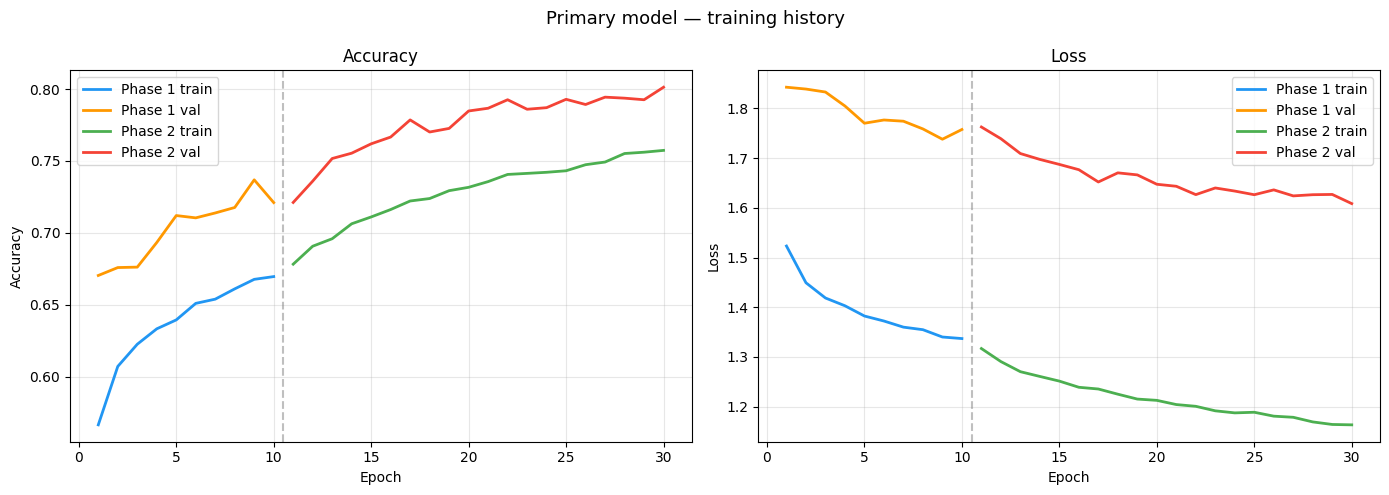

Saved training history plot → /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/models_v2/training_history.png


In [10]:
plot_history(
    [history_p1, history_p2],
    ['Phase 1', 'Phase 2'],
    save_path=MODELS_DIR / 'training_history.png'
)

## Cell 11 — Full evaluation on test set

In [11]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best weights before testing
primary_model.load_state_dict(torch.load(PHASE2_SAVE, map_location=DEVICE))
primary_model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(DEVICE)
        outputs = primary_model(images)
        probs   = torch.softmax(outputs, dim=1)
        preds   = probs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

test_acc = (all_preds == all_labels).mean()
top2_acc = sum(
    true in np.argsort(probs)[-2:]
    for true, probs in zip(all_labels, all_probs)
) / len(all_labels)

print(f'Test accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Top-2 accuracy : {top2_acc:.4f} ({top2_acc*100:.2f}%)')
print()

report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
print('Classification Report:')
print(report)

with open(MODELS_DIR / 'classification_report.txt', 'w') as f:
    f.write(f'Test accuracy : {test_acc:.4f}\n')
    f.write(f'Top-2 accuracy: {top2_acc:.4f}\n\n')
    f.write(report)
print(f'Report saved → {MODELS_DIR / "classification_report.txt"}')

Testing: 100%|████████████████████████████████████████████████████████████████████████| 312/312 [00:45<00:00,  6.80it/s]

Test accuracy  : 0.7989 (79.89%)
Top-2 accuracy : 0.9153 (91.53%)

Classification Report:
               precision    recall  f1-score   support

      e-waste     0.7822    0.9473    0.8569       474
general_trash     0.8746    0.8966    0.8855      1354
        glass     0.6390    0.9063    0.7495       619
    hazardous     0.5238    0.9795    0.6826       146
        metal     0.5209    0.9235    0.6661       392
      organic     0.9289    0.7828    0.8496      3490
        paper     0.7132    0.8650    0.7818      1133
      plastic     0.8252    0.6462    0.7248      2374

     accuracy                         0.7989      9982
    macro avg     0.7260    0.8684    0.7746      9982
 weighted avg     0.8255    0.7989    0.8016      9982

Report saved → /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/models_v2/classification_report.txt


## Cell 12 — Confusion matrix

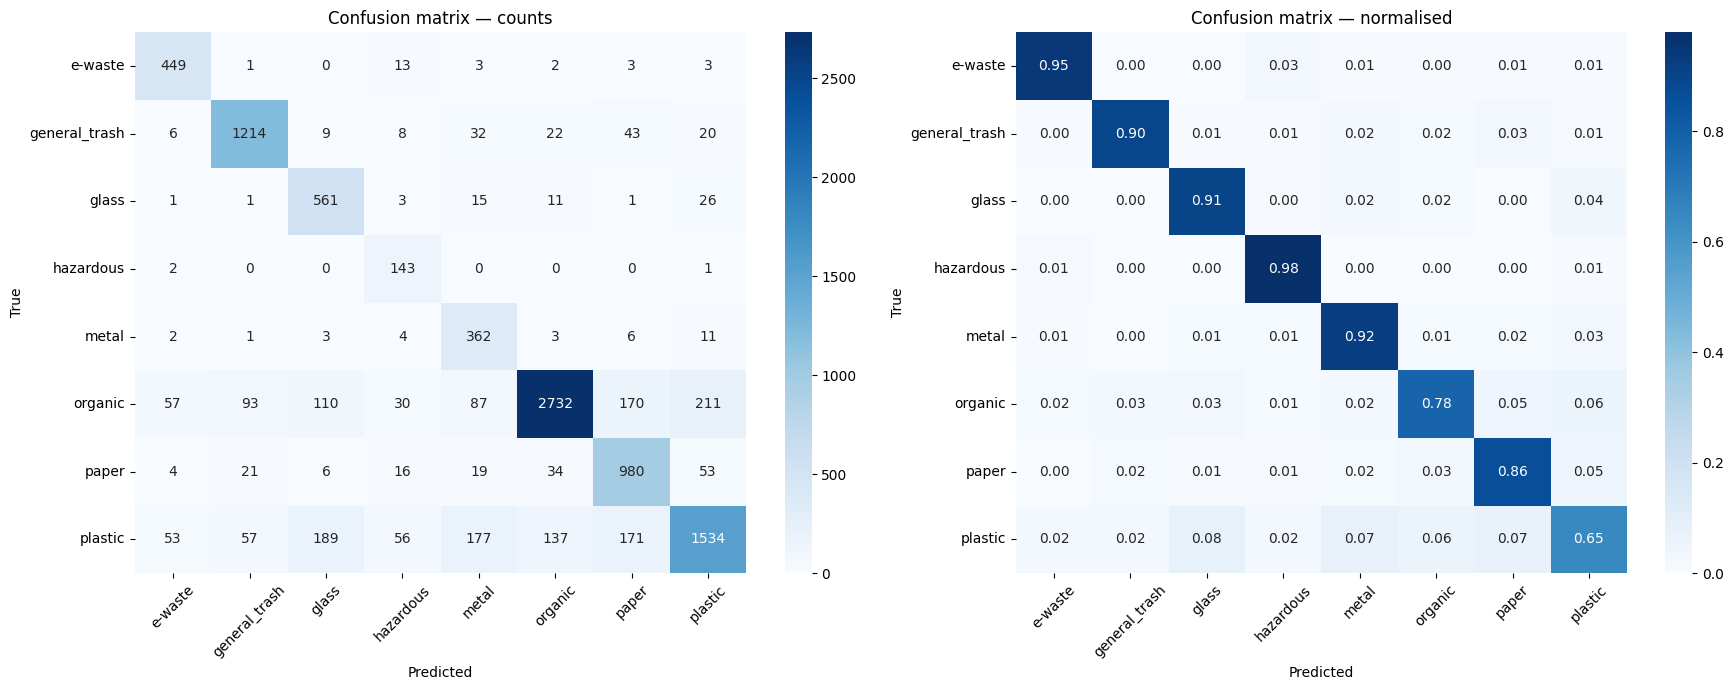

Saved → /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/models_v2/confusion_matrix.png


In [12]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion matrix — counts', 'Confusion matrix — normalised']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved → {MODELS_DIR / "confusion_matrix.png"}')

## Cell 13 — Export primary model (TorchScript for deployment)

In [13]:
import torch

# TorchScript — can be loaded anywhere without the class definition
primary_model.eval()
primary_model.to('cpu')  # export from CPU always

dummy_input   = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
traced_model  = torch.jit.trace(primary_model, dummy_input)
ts_path       = str(MODELS_DIR / 'primary_model_scripted.pt')
traced_model.save(ts_path)
print(f'TorchScript model saved → {ts_path}')

# Also save full checkpoint with metadata
checkpoint = {
    'model_state_dict' : primary_model.state_dict(),
    'class_to_idx'     : CLASS_TO_IDX,
    'idx_to_class'     : IDX_TO_CLASS,
    'class_names'      : CLASS_NAMES,
    'num_classes'      : NUM_CLASSES,
    'img_size'         : IMG_SIZE,
    'test_accuracy'    : float(test_acc),
    'imagenet_mean'    : IMAGENET_MEAN,
    'imagenet_std'     : IMAGENET_STD,
}
ckpt_path = str(MODELS_DIR / 'primary_checkpoint.pth')
torch.save(checkpoint, ckpt_path)
print(f'Full checkpoint saved  → {ckpt_path}')

# Move back to device for rest of notebook
primary_model.to(DEVICE)

size_mb = os.path.getsize(ckpt_path) / (1024*1024)
print(f'Checkpoint size: {size_mb:.1f} MB')

TorchScript model saved → /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/models_v2/primary_model_scripted.pt
Full checkpoint saved  → /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/models_v2/primary_checkpoint.pth
Checkpoint size: 16.8 MB


## Cell 14 — Secondary model: condition classifier (clean vs contaminated)
Skips automatically if `condition_train/` folder doesn't exist in your dataset yet.

In [14]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

COND_TRAIN = DATASET_PATH / 'condition_train'
COND_VAL   = DATASET_PATH / 'condition_val'
COND_TEST  = DATASET_PATH / 'condition_test'

has_condition = all(d.exists() for d in [COND_TRAIN, COND_VAL, COND_TEST])

if not has_condition:
    print('Condition split not found — skipping secondary model.')
    print('Expected folder structure:')
    print(f'  {COND_TRAIN}/clean/')
    print(f'  {COND_TRAIN}/contaminated/')
    print('  (same for condition_val/ and condition_test/)')
else:
    COND_CLASS_TO_IDX = {'clean': 0, 'contaminated': 1}
    COND_IDX_TO_CLASS = {0: 'clean', 1: 'contaminated'}

    cond_train_ds = WasteDataset(COND_TRAIN, COND_CLASS_TO_IDX, train_transform)
    cond_val_ds   = WasteDataset(COND_VAL,   COND_CLASS_TO_IDX, val_transform)
    cond_test_ds  = WasteDataset(COND_TEST,  COND_CLASS_TO_IDX, val_transform)

    cond_train_loader = DataLoader(cond_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                   num_workers=NUM_WORKERS, persistent_workers=True)
    cond_val_loader   = DataLoader(cond_val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                                   num_workers=NUM_WORKERS, persistent_workers=True)
    cond_test_loader  = DataLoader(cond_test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                                   num_workers=NUM_WORKERS, persistent_workers=True)

    # Build MobileNetV2
    cond_model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    for param in cond_model.parameters():
        param.requires_grad = False
    in_f = cond_model.classifier[1].in_features
    cond_model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_f, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 2)
    )
    cond_model = cond_model.to(DEVICE)

    cond_criterion = nn.CrossEntropyLoss()
    cond_optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, cond_model.parameters()), lr=COND_LR
    )
    cond_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        cond_optimizer, mode='min', factor=0.5, patience=3, 
    )

    COND_SAVE = str(MODELS_DIR / 'condition_best.pth')

    print('='*55)
    print('CONDITION MODEL — MobileNetV2')
    print(f'Train: {len(cond_train_ds):,}  Val: {len(cond_val_ds):,}  Test: {len(cond_test_ds):,}')
    print('='*55)

    cond_history = run_training(
        cond_model, cond_train_loader, cond_val_loader,
        cond_criterion, cond_optimizer, cond_scheduler,
        epochs=COND_EPOCHS, device=DEVICE,
        save_path=COND_SAVE, phase_name='Condition'
    )

    # Test
    cond_model.load_state_dict(torch.load(COND_SAVE, map_location=DEVICE))
    cond_model.eval()
    cond_preds, cond_true = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(cond_test_loader, desc='Condition test'):
            out = cond_model(imgs.to(DEVICE))
            cond_preds.extend(out.argmax(1).cpu().numpy())
            cond_true.extend(lbls.numpy())

    cond_acc = (np.array(cond_preds) == np.array(cond_true)).mean()
    print(f'\nCondition model test accuracy: {cond_acc:.4f} ({cond_acc*100:.2f}%)')
    print(classification_report(cond_true, cond_preds,
                                 target_names=['clean','contaminated'], digits=4))

    # Save checkpoint
    cond_ckpt_path = str(MODELS_DIR / 'condition_checkpoint.pth')
    torch.save({
        'model_state_dict' : cond_model.state_dict(),
        'class_to_idx'     : COND_CLASS_TO_IDX,
        'test_accuracy'    : float(cond_acc),
    }, cond_ckpt_path)
    print(f'Condition checkpoint saved → {cond_ckpt_path}')

Condition split not found — skipping secondary model.
Expected folder structure:
  /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/dataset_v2/condition_train/clean/
  /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/dataset_v2/condition_train/contaminated/
  (same for condition_val/ and condition_test/)


## Cell 15 — Confidence-aware inference function

In [15]:
from torchvision import transforms
from PIL import Image
import torch, numpy as np

HIGH_CONFIDENCE   = 0.80
MEDIUM_CONFIDENCE = 0.55
HAZARDOUS_OFFSET  = 0.10   # lower threshold for hazardous class

_infer_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def predict_waste(image_path, model=None, idx_to_class=None,
                  cond_model=None, cond_idx_to_class=None, device=None):
    """
    Confidence-aware inference on a single image file.
    Returns a dict ready to pass to your web app's response.
    """
    if model is None:        model         = primary_model
    if idx_to_class is None: idx_to_class  = IDX_TO_CLASS
    if device is None:       device        = DEVICE

    try:
        img = Image.open(image_path).convert('RGB')
    except Exception as e:
        return {'error': f'Cannot open image: {e}'}

    tensor = _infer_transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx   = int(np.argmax(probs))
    pred_class = idx_to_class[pred_idx]
    confidence = float(probs[pred_idx])

    top3 = [
        (idx_to_class[i], float(probs[i]))
        for i in np.argsort(probs)[::-1][:3]
    ]

    # Adjust thresholds for hazardous class
    is_hazardous = (pred_class == 'hazardous')
    hi  = HIGH_CONFIDENCE   - (HAZARDOUS_OFFSET if is_hazardous else 0)
    med = MEDIUM_CONFIDENCE - (HAZARDOUS_OFFSET if is_hazardous else 0)

    if confidence >= hi:
        tier   = 'high'
        prefix = ''
    elif confidence >= med:
        tier   = 'medium'
        prefix = 'Likely '
    else:
        tier   = 'low'
        prefix = 'Uncertain — '

    result = {
        'predicted_class'  : pred_class,
        'confidence'       : round(confidence, 4),
        'confidence_tier'  : tier,
        'guidance_prefix'  : prefix,
        'top3'             : top3,
        'condition'        : None,
        'condition_confidence': None,
    }

    # Optional condition model
    if cond_model is not None:
        cond_model.eval()
        with torch.no_grad():
            cond_logits = cond_model(tensor)
            cond_probs  = torch.softmax(cond_logits, dim=1).cpu().numpy()[0]
        cond_idx = int(np.argmax(cond_probs))
        cond_label = (cond_idx_to_class or {0:'clean',1:'contaminated'}).get(cond_idx, 'unknown')
        result['condition']            = cond_label
        result['condition_confidence'] = round(float(cond_probs[cond_idx]), 4)

    return result

print('predict_waste() ready.')
print('Usage: predict_waste("path/to/photo.jpg")')

predict_waste() ready.
Usage: predict_waste("path/to/photo.jpg")


## Cell 16 — Visual test predictions

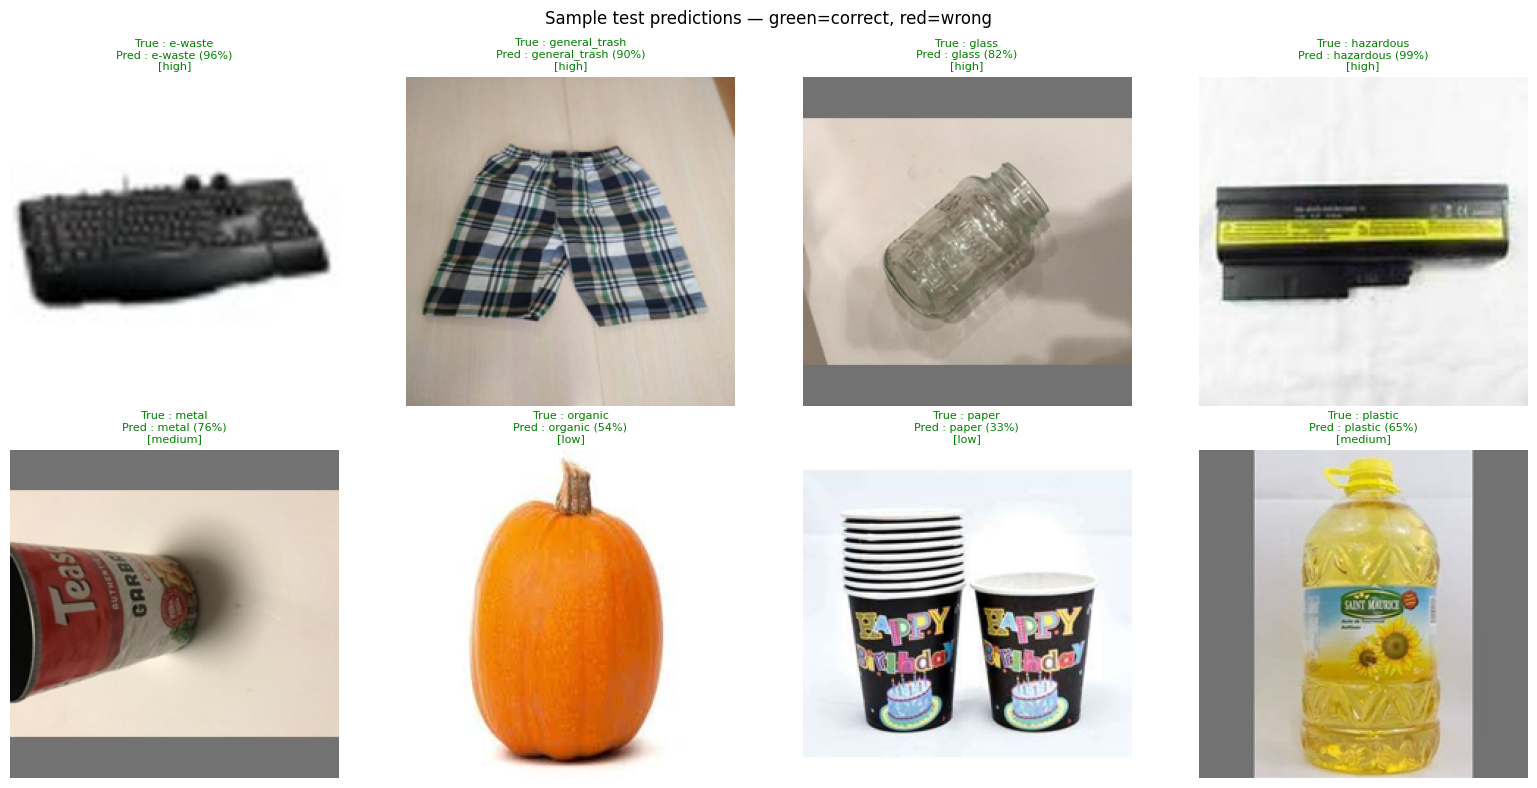

Saved → /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/models_v2/sample_predictions.png


In [16]:
import random, matplotlib.pyplot as plt
from PIL import Image

rows = (NUM_CLASSES + 3) // 4
fig, axes = plt.subplots(rows, 4, figsize=(16, rows * 4))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    cls_dir = TEST_DIR / cls
    imgs = [f for f in cls_dir.iterdir() if f.suffix.lower() in VALID_EXT]
    if not imgs:
        axes[i].set_visible(False)
        continue
    sample = random.choice(imgs)
    result = predict_waste(str(sample))
    if 'error' in result:
        axes[i].set_visible(False)
        continue
    try:
        img = Image.open(sample).convert('RGB').resize((224, 224))
        axes[i].imshow(img)
    except Exception:
        axes[i].set_visible(False)
        continue

    correct = result['predicted_class'] == cls
    color   = 'green' if correct else 'red'
    title   = (f"True : {cls}\n"
               f"Pred : {result['predicted_class']} "
               f"({result['confidence']:.0%})\n"
               f"[{result['confidence_tier']}]")
    if result['condition']:
        title += f" | {result['condition']}"
    axes[i].set_title(title, fontsize=8, color=color)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sample test predictions — green=correct, red=wrong', fontsize=12)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'sample_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved → {MODELS_DIR / "sample_predictions.png"}')

## Cell 17 — Final summary

In [17]:
print('='*55)
print('  GROUP 51 — TRAINING COMPLETE')
print('='*55)
print(f'  Test accuracy  : {test_acc*100:.2f}%')
print(f'  Top-2 accuracy : {top2_acc*100:.2f}%')
if has_condition:
    print(f'  Condition acc  : {cond_acc*100:.2f}%')
print()
print(f'  All outputs in: {MODELS_DIR}')
print()

expected_files = [
    'primary_best.pth',
    'primary_checkpoint.pth',
    'primary_model_scripted.pt',
    'class_indices.json',
    'classification_report.txt',
    'training_history.png',
    'confusion_matrix.png',
    'sample_images.png',
    'sample_predictions.png',
]
if has_condition:
    expected_files += ['condition_best.pth', 'condition_checkpoint.pth']

for fname in expected_files:
    fpath = MODELS_DIR / fname
    status = 'OK    ' if fpath.exists() else 'MISSING'
    size   = f'({fpath.stat().st_size / (1024*1024):.1f} MB)' if fpath.exists() else ''
    print(f'  {status}  {fname} {size}')

print()
print('  Next step: use primary_checkpoint.pth in your Flask backend')
print('='*55)

  GROUP 51 — TRAINING COMPLETE
  Test accuracy  : 79.89%
  Top-2 accuracy : 91.53%

  All outputs in: /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/models_v2

  OK      primary_best.pth (16.8 MB)
  OK      primary_checkpoint.pth (16.8 MB)
  OK      primary_model_scripted.pt (17.4 MB)
  OK      class_indices.json (0.0 MB)
  OK      classification_report.txt (0.0 MB)
  OK      training_history.png (0.1 MB)
  OK      confusion_matrix.png (0.1 MB)
  OK      sample_images.png (0.8 MB)
  OK      sample_predictions.png (0.8 MB)

  Next step: use primary_checkpoint.pth in your Flask backend
